# Exploratory Data Analysis

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('../dataset/heart_disease.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                304 non-null    int64  
 1   Sex                                304 non-null    str    
 2   Chest Pain                         304 non-null    str    
 3   Resting BP                         304 non-null    float64
 4   Serum Cholestrol(mg/dl)            304 non-null    float64
 5   Fasting Blood Sugar (> 120 mg/dl)  304 non-null    bool   
 6   Resting ECG Result                 304 non-null    str    
 7   Max Heart Rate                     304 non-null    float64
 8   Angina (Exercise Induced)          304 non-null    bool   
 9   Oldpeak                            304 non-null    float64
 10  Slope                              303 non-null    str    
 11  No. of Major Vessels               299 non-null    float64
 12  Thal 

In [15]:
df.describe()

,Age,Resting BP,Serum Cholestrol(mg/dl),Max Heart Rate,Oldpeak,No. of Major Vessels,Target
count,304.000000,304.000000,304.000000,304.000000,304.000000,299.000000,304.000000
mean,54.351974,131.684211,246.315789,149.723684,1.036184,0.672241,0.457237
std,9.150256,17.570949,52.108280,22.927263,1.160690,0.937438,0.498989
min,28.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,47.750000,120.000000,211.000000,133.750000,0.000000,0.000000,0.000000
50%,55.500000,130.000000,240.500000,153.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,1.000000


In [16]:
df.head()

,Age,Sex,Chest Pain,Resting BP,Serum Cholestrol(mg/dl),Fasting Blood Sugar (> 120 mg/dl),Resting ECG Result,Max Heart Rate,Angina (Exercise Induced),Oldpeak,Slope,No. of Major Vessels,Thal,Target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
continuous_features = ['Age', 'Resting BP', 'Serum Cholestrol(mg/dl)', 'Max Heart Rate', 'Oldpeak', 'No. of Major Vessels']
discrete_features = ['Sex', 'Chest Pain', 'Fasting Blood Sugar (> 120 mg/dl)', 'Resting ECG Result', 'Angina (Exercise Induced)', 'Slope', 'Thal', 'Target']

## Univariate Analysis

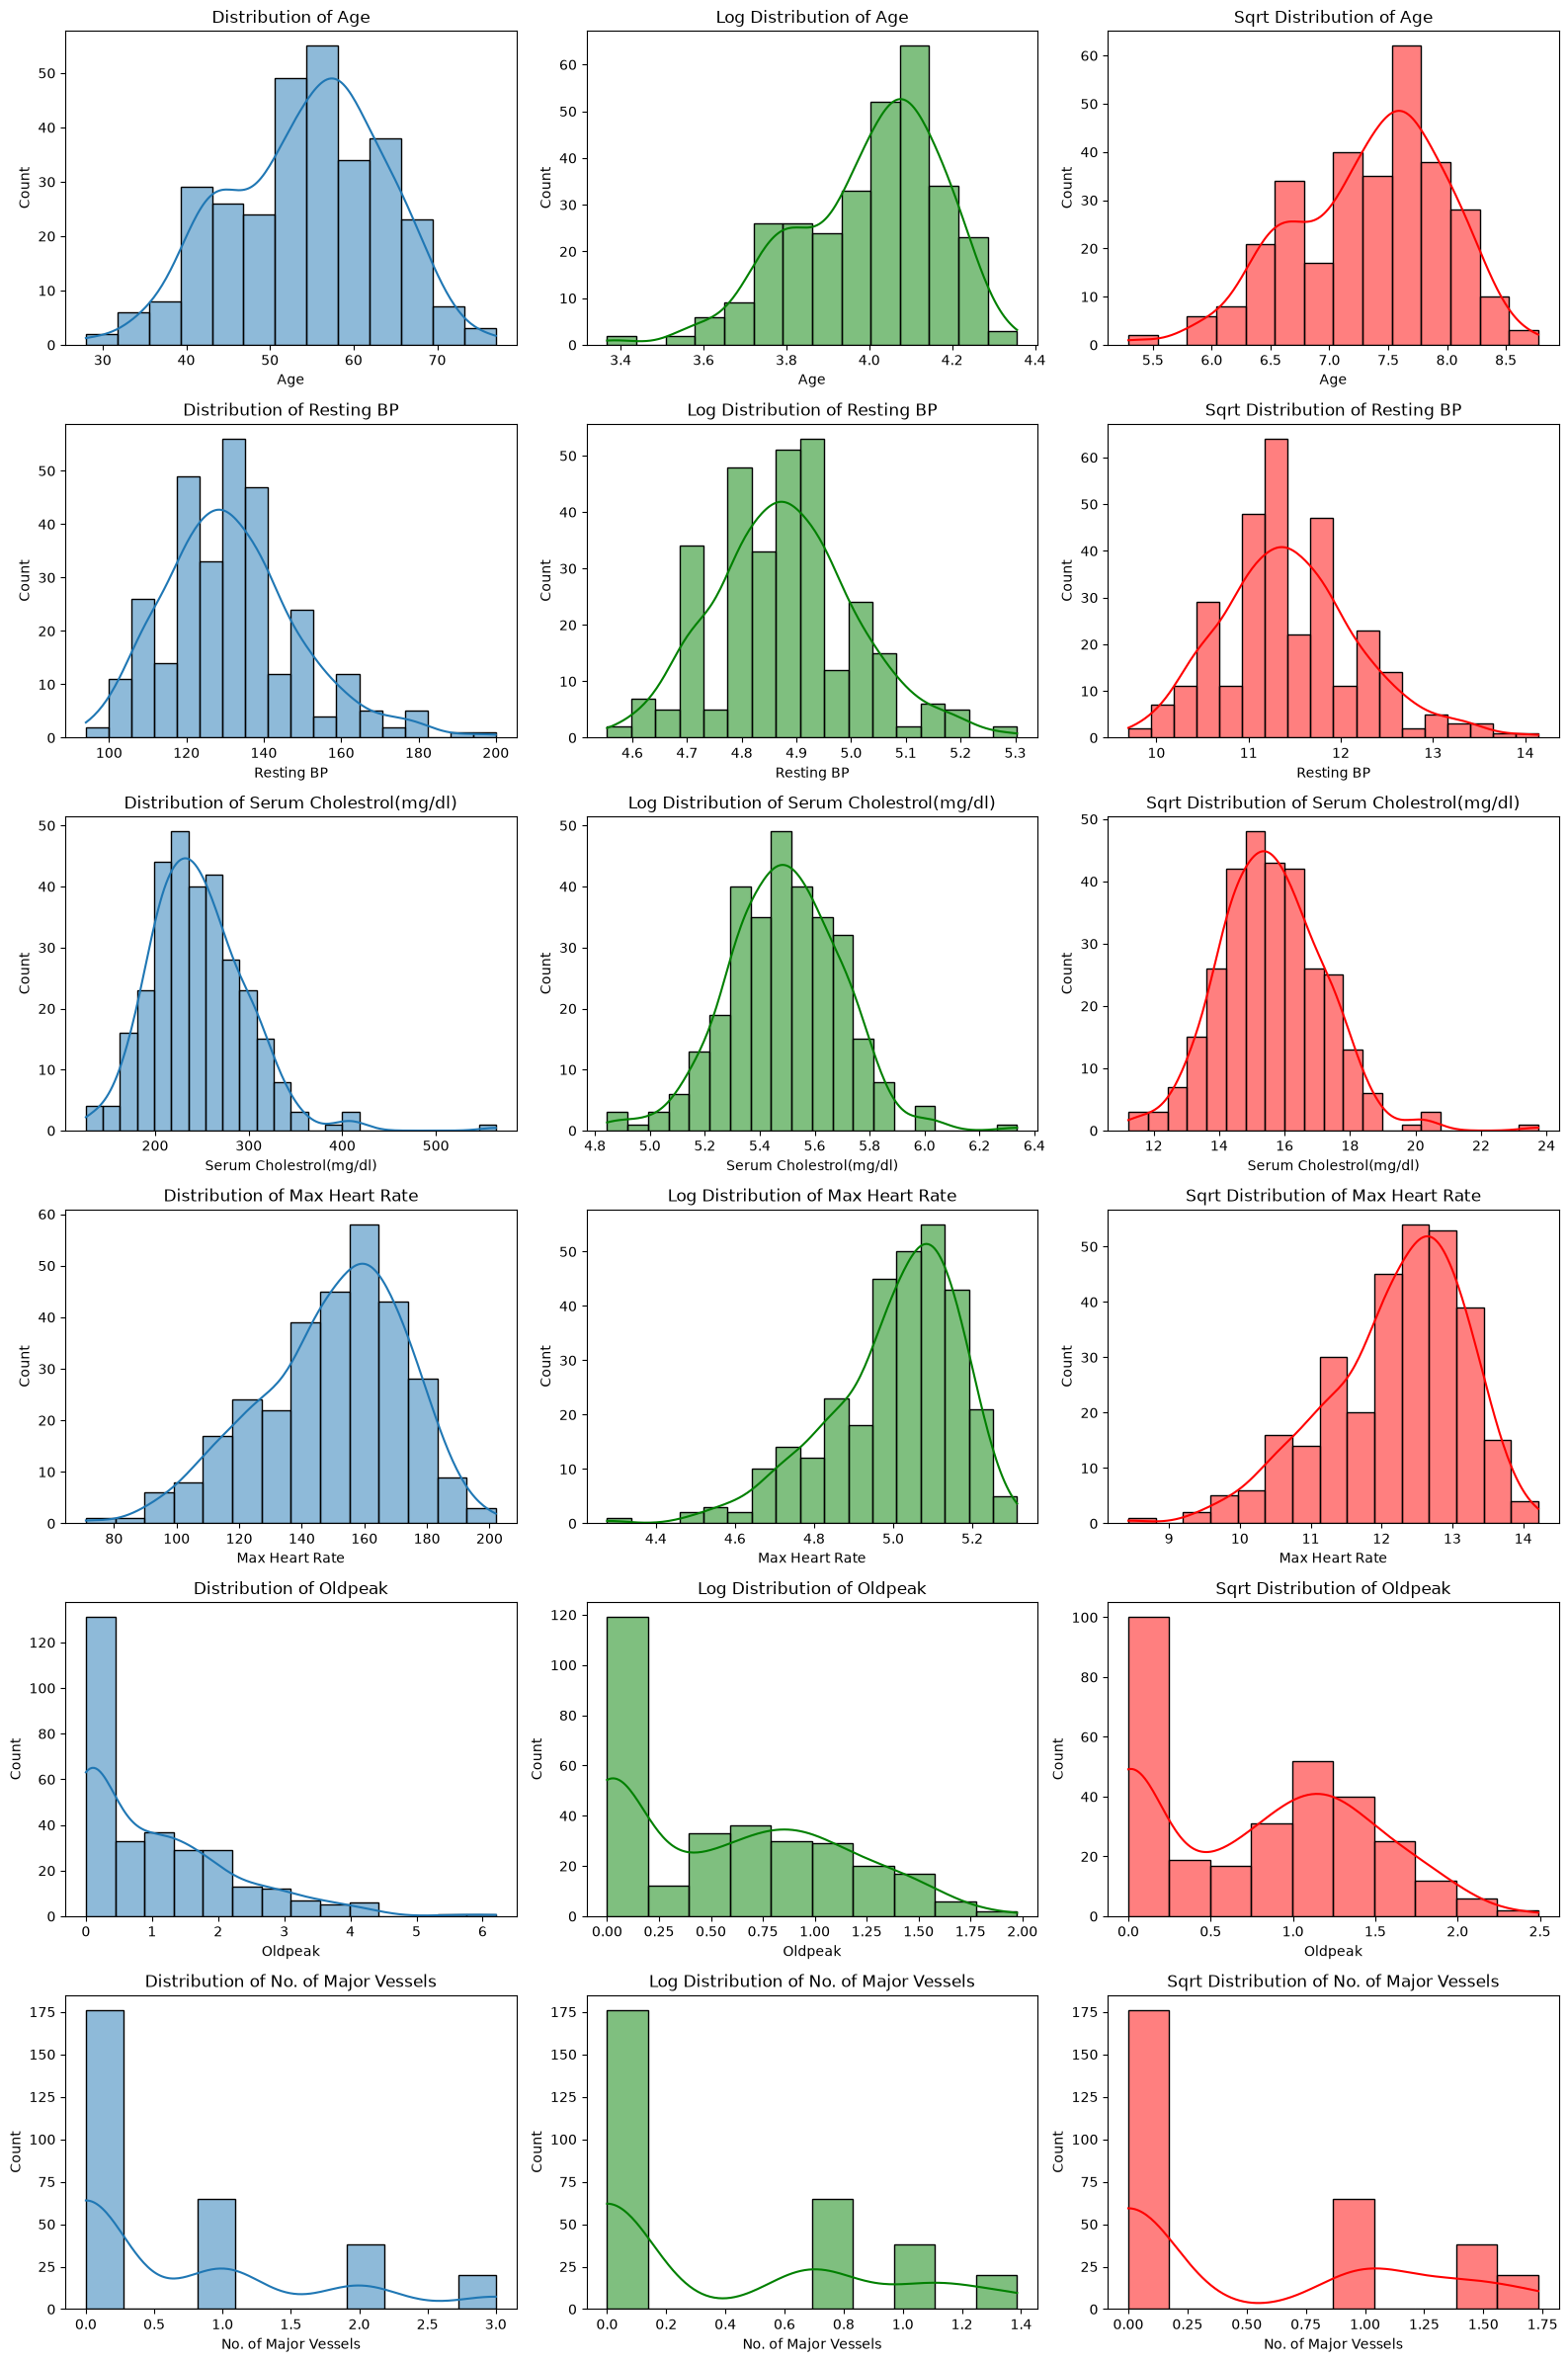

In [19]:
fig, axes = plt.subplots(len(continuous_features), 3, figsize=(16, 4
*len(continuous_features)))

for i,col in enumerate(continuous_features):

    sns.histplot(df[col], kde=True, ax=axes[i][0])
    axes[i][0].set_title(f"Distribution of {col}")

    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i][1], color='green')
    axes[i][1].set_title(f"Log Distribution of {col}")

    sns.histplot(np.sqrt(df[col]), kde=True, ax=axes[i][2], color='red')
    axes[i][2].set_title(f"Sqrt Distribution of {col}")

plt.tight_layout()
plt.show()

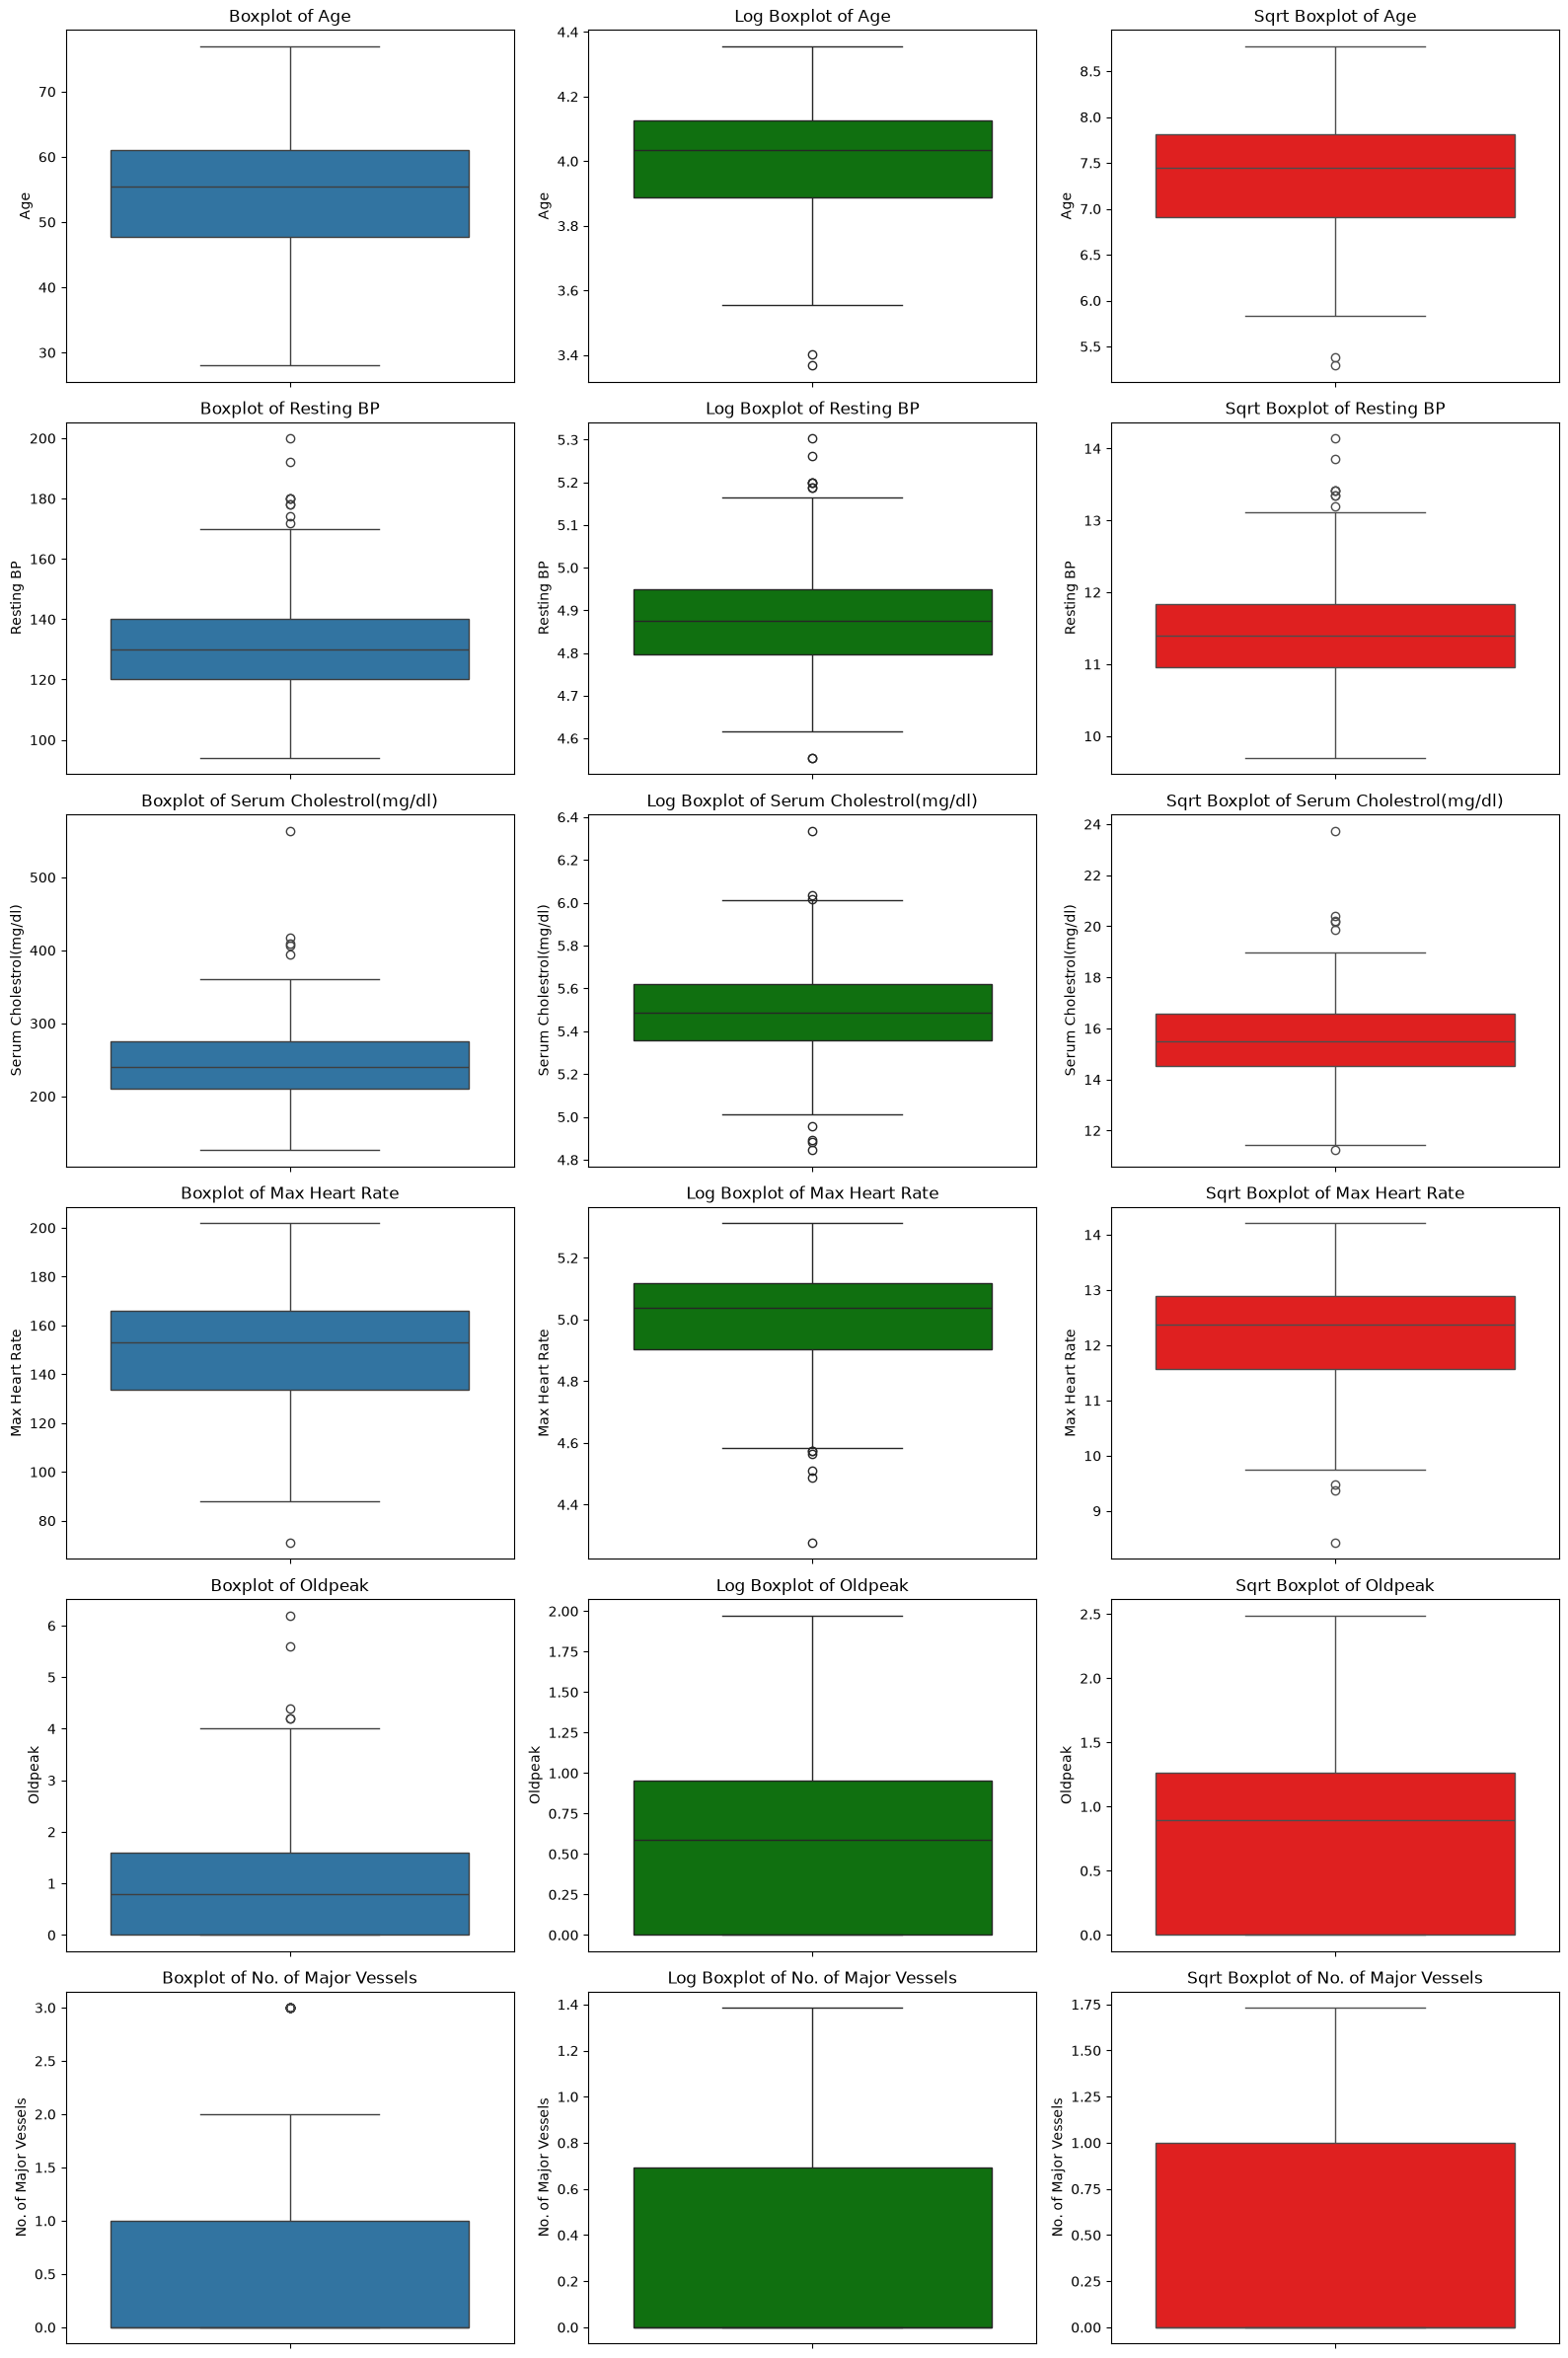

In [20]:
fig, axes = plt.subplots(len(continuous_features), 3, figsize=(16, 4
*len(continuous_features)))

for i,col in enumerate(continuous_features):

    sns.boxplot(df[col], ax=axes[i][0])
    axes[i][0].set_title(f"Boxplot of {col}")

    sns.boxplot(np.log1p(df[col]), ax=axes[i][1], color='green')
    axes[i][1].set_title(f"Log Boxplot of {col}")

    sns.boxplot(np.sqrt(df[col]), ax=axes[i][2], color='red')
    axes[i][2].set_title(f"Sqrt Boxplot of {col}")

plt.tight_layout()
plt.show()

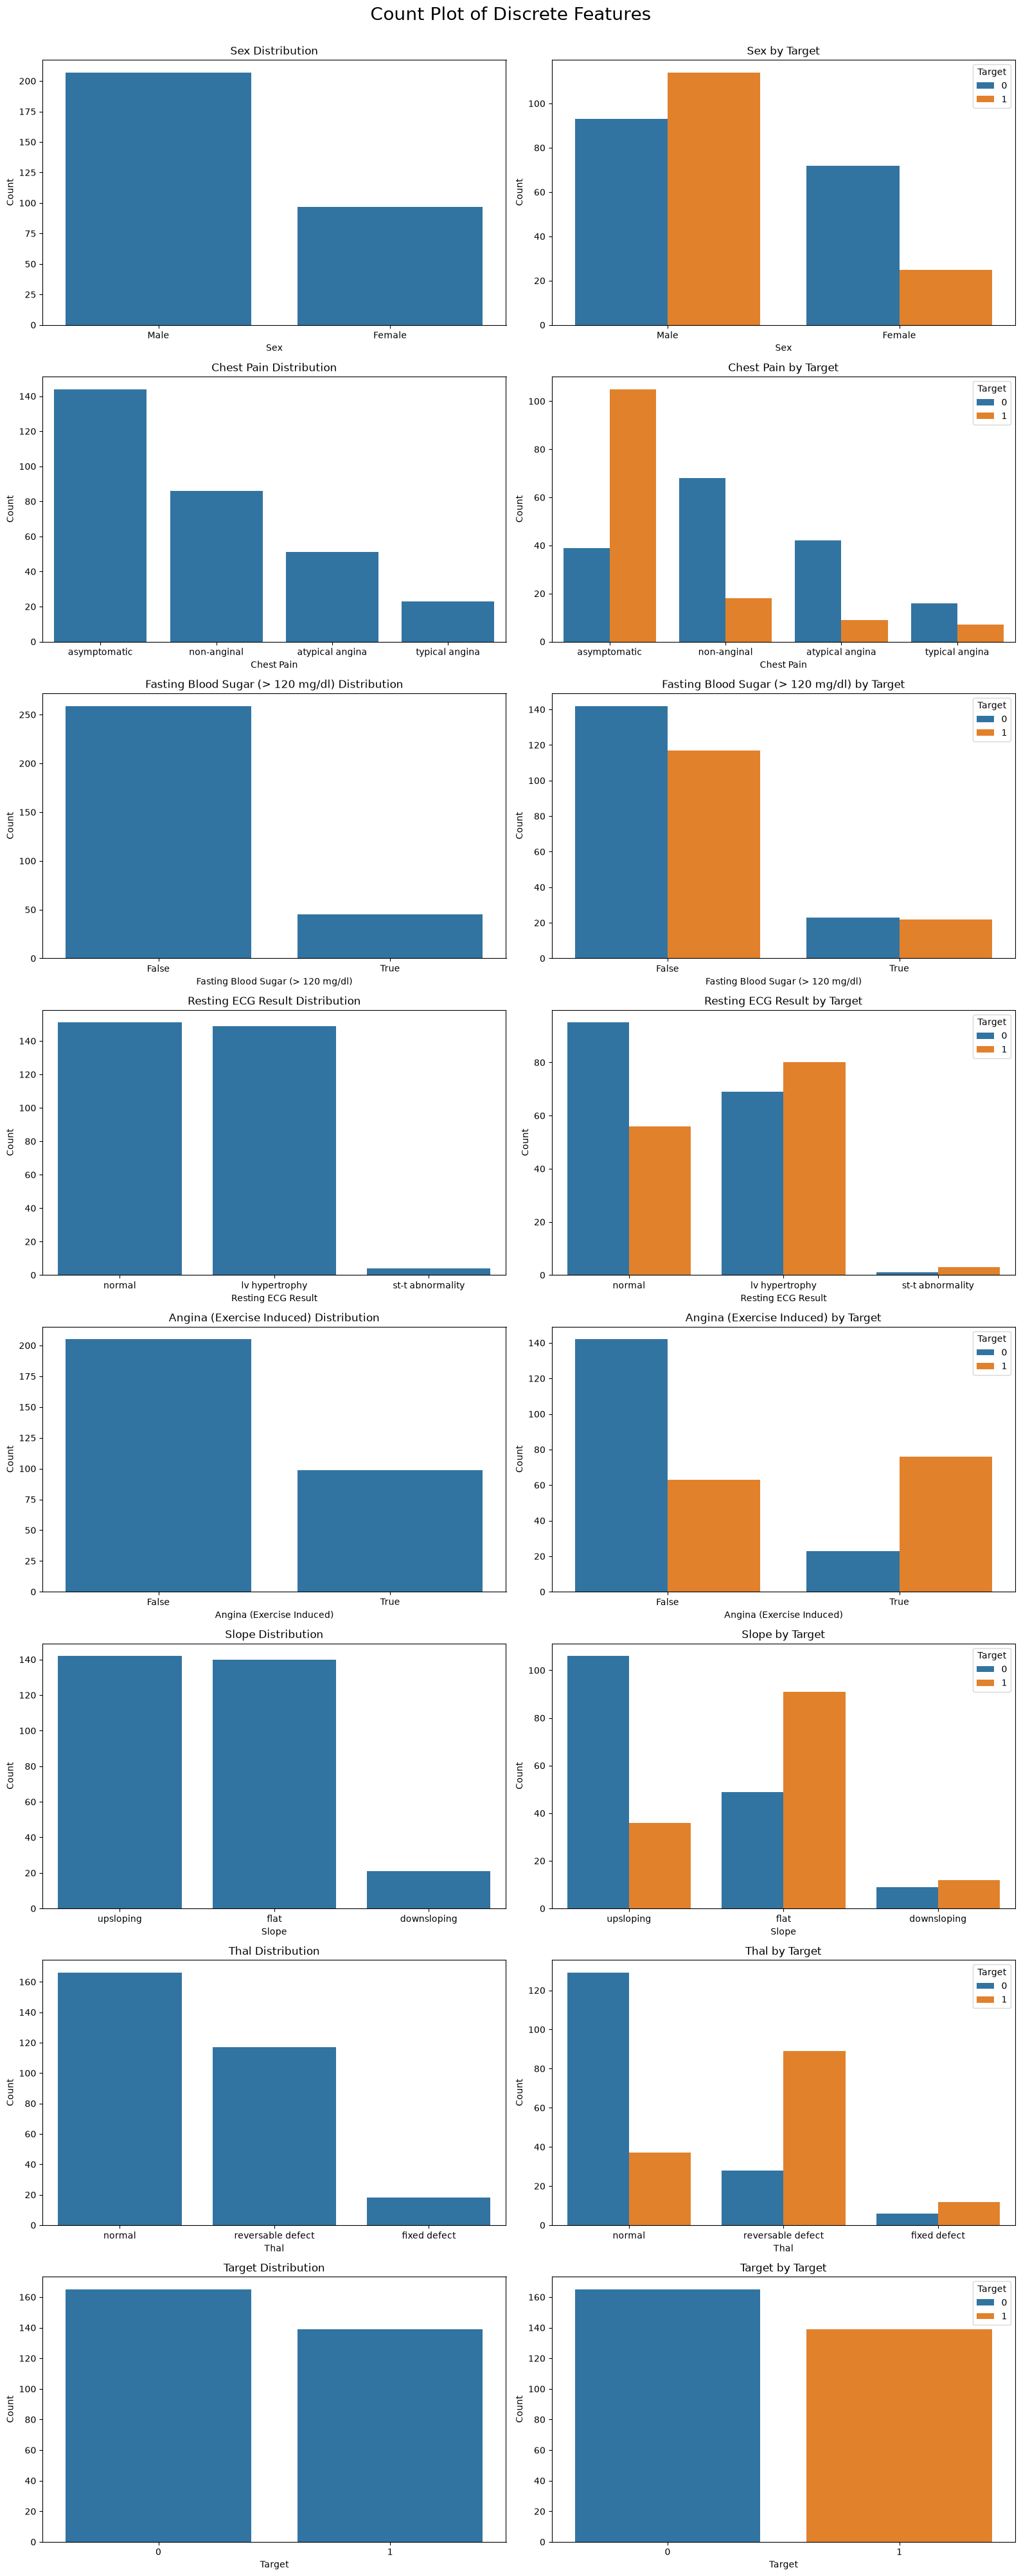

In [21]:
n_rows = len(discrete_features)

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))

for i, col in enumerate(discrete_features):
    order = df[col].value_counts().index

    sns.countplot(df, x=col, ax=axes[i][0], order=order)
    axes[i][0].set_title(f'{col} Distribution')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')

    sns.countplot(df, x=col, hue='Target', ax=axes[i][1], order=order)
    axes[i][1].set_title(f'{col} by Target')
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel('Count')


fig.suptitle("Count Plot of Discrete Features", y=1.001, fontsize=20)
plt.tight_layout()
plt.show()

## Bivariate Analysis

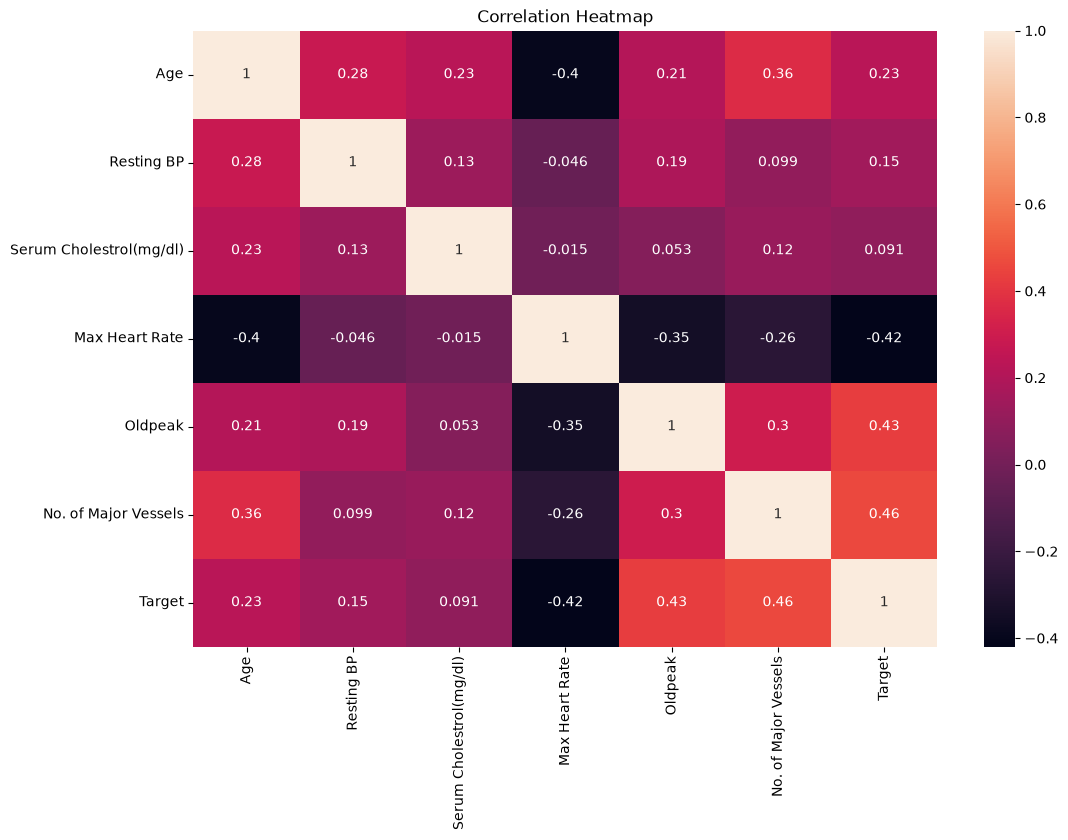

In [22]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Observations

## Histogram Observations

1. Age is approximately normally distributed, with most patients between 40 and 65 years.
2. Resting Blood Pressure and Serum Cholesterol show right-skewed distributions with a few high-value observations.
3. Max Heart Rate is fairly bell-shaped, indicating a near-normal distribution.
4. Oldpeak and Number of Major Vessels are highly skewed, with most values concentrated at the lower end.

## Boxplot Observations

1. Resting Blood Pressure and Serum Cholesterol contain several outliers above the upper whisker.
2. Oldpeak shows many extreme values, indicating the presence of significant outliers.
3. Age has a relatively balanced spread with very few outliers.
4. Max Heart Rate has a few low-value outliers but remains fairly consistent overall.

## Count Plot Observations

1. The dataset contains more male patients than female patients.
2. Asymptomatic chest pain is the most common chest pain type and is frequently associated with heart disease.
3. Exercise-induced angina appears more often among patients with heart disease.
4. The target classes are reasonably balanced, with similar numbers of patients in both categories.

## Heatmap Observations

1. Number of Major Vessels and Oldpeak have the strongest positive correlation with the target variable (0.46, 0.43).
2. Max Heart Rate has a moderate negative correlation with the target variable (-0.42).
3. Serum Cholesterol and Resting Blood Pressure have weak correlations with the target variable, suggesting limited direct influence.